# Equity Implied Correlation Analysis

The overall goal of this notebook is to analyze the following

Conditioning Returns under different implied correlation structures
1. Examine the benchmark returns
2. Examine the self replicated returns

Examining the factor exposure of to the returns

Plugging it into returns a model and then scaling the signal by the returns

# Packages

In [40]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from   sklearn.decomposition import PCA

import statsmodels.api as sm
from   statsmodels.regression.rolling import RollingOLS

# Path Management and Data

In [2]:
misc_path      = os.getcwd()
research_path  = os.path.abspath(os.path.join(misc_path, ".."))
repo_path      = os.path.abspath(os.path.join(research_path, ".."))
data_path      = os.path.join(repo_path, "data")
trend_idx_path = os.path.join(data_path, "TrendIndices")

In [3]:
trend_px_path = os.path.join(trend_idx_path, "RawTrendIndices.parquet")
trend_tickers = os.path.join(trend_idx_path, "TrendIndicesGuide.xlsx")

df_trend_tickers = df_trend_tickers = (pd.read_excel(
    io = trend_tickers, sheet_name = "TrendIndices").
    rename(columns = {"Asset Class": "asset_class"}).
    query("asset_class == 'Equity'").
    query("Currency == 'USD'").
    dropna()
    [["Ticker", "Name", "Holding", "PlotName"]].
    melt(id_vars = "Ticker").
    rename(columns = {"Ticker": "ticker"}).
    assign(
        ticker   = lambda x: x.ticker.str.split(" ").str[0],
        variable = lambda x: x.variable.str.lower()).
    pivot(index = "ticker", columns = "variable", values = "value").
    reset_index())

trend_tickers = df_trend_tickers.ticker.drop_duplicates().sort_values().to_list()

In [4]:
df_trend = (pd.read_parquet(
    path = trend_px_path, engine = "pyarrow").
    assign(ticker = lambda x: x.security.str.split(" ").str[0]).
    query("ticker == @trend_tickers").
    drop(columns = ["security"]))

In [5]:
misc_data_path = os.path.join(data_path, "MiscData")
cboe_path      = os.path.join(misc_data_path, "CleanedCBOEImpliedCorrelation.parquet")
bbg_path       = os.path.join(misc_data_path, "CleanedImpliedRealCorrelation.parquet")

df_cboe = (pd.read_parquet(
    path   = cboe_path, 
    engine = "pyarrow").
    drop(columns = ["value"]).
    rename(columns = {
        "Date"     : "date",
        "clean_val": "value"}).
    assign(variable = lambda x: x.variable.str.split(" ").str[0]))

df_bbg = (pd.read_parquet(
    path   = bbg_path, 
    engine = "pyarrow").
    rename(columns = {"Date": "date"}).
    drop(columns = ["value"]).
    rename(columns = {"clean_val": "value"}))

In [6]:
path = os.path.join(misc_data_path, "ImpliedCorrelationTickerGuide.xlsx")

df_cboe_tickers = (pd.read_excel(
    io = path, sheet_name = "CBOEGuide").
    rename(columns = {"Ticker": "ticker"}).
    melt(id_vars = "ticker").
    assign(
        ticker   = lambda x: x.ticker.str.split(" ").str[0],
        variable = lambda x: x.variable.str.replace(" ", "_").str.lower()).
    pivot(index = "ticker", columns = "variable", values = "value").
    reset_index())

# Examining the Data

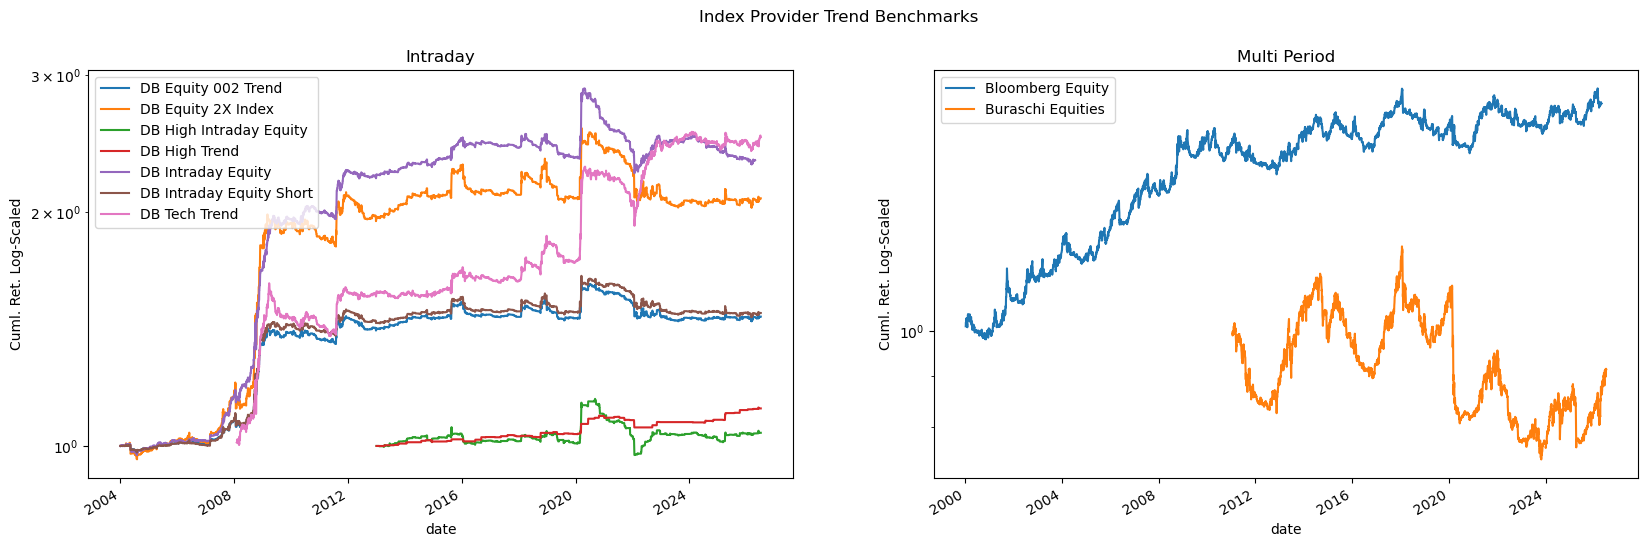

In [7]:
holding_periods = df_trend_tickers.holding.drop_duplicates().sort_values().to_list()
fig, axes       = plt.subplots(ncols = len(holding_periods), figsize = (20,6))

for holding_period, ax in zip(holding_periods, axes.flatten()):
    
    tickers = (df_trend_tickers.query(
        "holding == @holding_period").
        ticker.
        drop_duplicates().
        sort_values().
        to_list())
    
    (df_trend.query(
        "ticker == @tickers").
        merge(right = df_trend_tickers, how = "inner", on = ["ticker"]).
        rename(columns = {"plotname": ""}).
        pivot(index = "date", columns = "", values = "PX_LAST").
        pct_change().
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True, 
            ax     = ax,
            title  = holding_period,
            ylabel = "Cuml. Ret. Log-Scaled"))

fig.suptitle("Index Provider Trend Benchmarks")
plt.show()

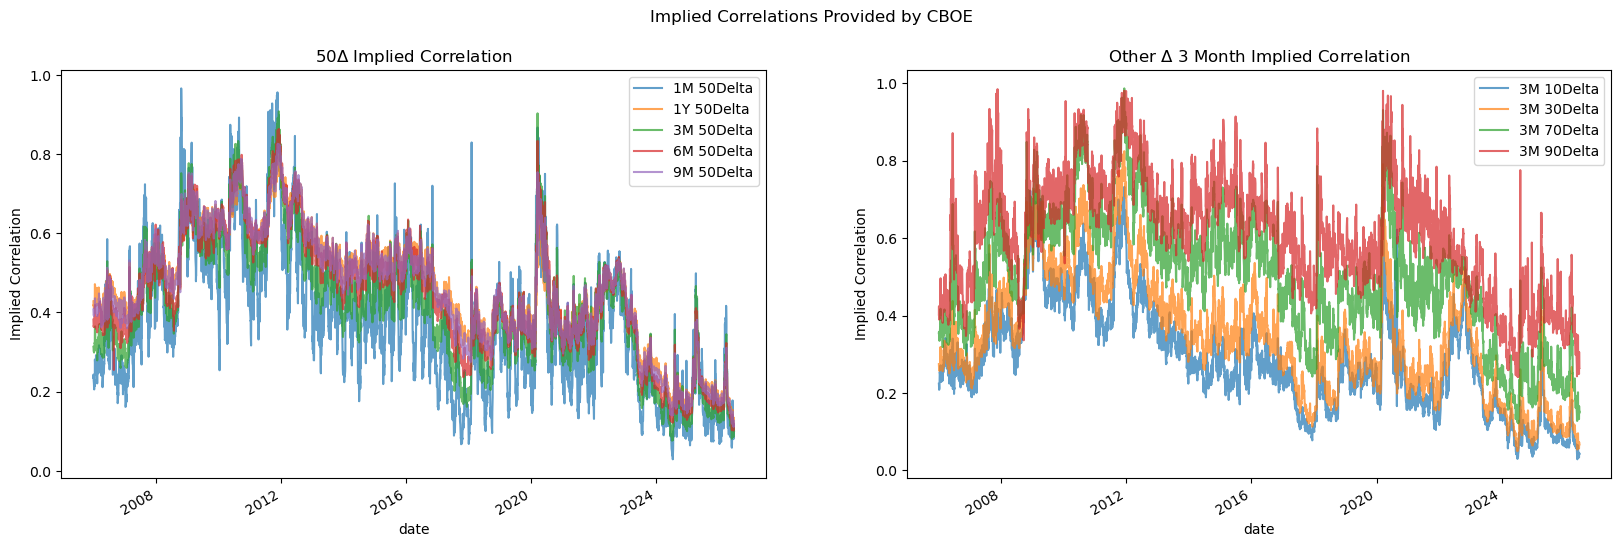

In [8]:
df_tmp = (df_cboe.rename(columns = {
    "variable": "ticker"}).
    merge(right = df_cboe_tickers, how = "inner", on = ["ticker"]))

fig, axes = plt.subplots(ncols = 2, figsize = (20,6))

(df_tmp.query(
    "delta == 50").
    rename(columns = {"plot_name": ""}).
    pivot(index = "date", columns = "", values = "value").
    plot(
        ax     = axes[0],
        alpha  = 0.7,
        ylabel = "Implied Correlation",
        title  = "50$\Delta$ Implied Correlation"))

(df_tmp.query(
    "delta != 50").
    rename(columns = {"plot_name": ""}).
    pivot(index = "date", columns = "", values = "value").
    plot(
        ax     = axes[1],
        alpha  = 0.7,
        ylabel = "Implied Correlation",
        title  = r"Other $\Delta$ 3 Month Implied Correlation"))

fig.suptitle("Implied Correlations Provided by CBOE")
plt.show()

# Multi-Day Trend OLS Driver

Although the CBOE implied correlation is tied to SPX returns while the Equity Trend Indices combine an unkown amount of equity futures. Its not a perfect comparison but it gives a good starting point. In 
this case we'll run regressions for the following indices
1. BSLEQT Index - Bloomberg Equity Trend Index
2. BXIIBATE Index - Buraschi Barclays Adaptive Trend Index - Equities

With two sets of endogenous variables
1. The whole term structure of the 50$\Delta$ Implied Correlation
2. All the available $\Delta$ of the 3 Month Implied Correlation

With 3 kinds of transformation
1. 30d Level Exponentially weighted z-score
2. Differenced values

All values are lagged to test their predictveness

In [9]:
def get_prep_corr(df_cboe: pd.DataFrame) -> pd.DataFrame:

    df_wider = (df_cboe.pivot(
        index = "date", columns = "variable", values = "value"))
    
    window = 30
    
    df_zscore = (df_wider.apply(
        lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
        shift().
        reset_index().
        melt(id_vars = ["date"]).
        assign(var_type = "z_score"))
    
    df_diff = (df_wider.diff().shift().reset_index().melt(
        id_vars = "date", value_name = "value").
        assign(var_type = "diff_val"))

    df_out = pd.concat([df_zscore, df_diff])
    return df_out

df_exog = get_prep_corr(df_cboe)

In [10]:
multi_holding_tickers = (df_trend_tickers.query(
    "holding == 'Multi Period'").
    ticker.
    to_list())

In [11]:
df_trend_rtn = (df_trend.query(
    "ticker == @multi_holding_tickers").
    pivot(index = "date", columns = "ticker", values = "PX_LAST").
    pct_change().
    reset_index().
    melt(id_vars = "date", value_name = "rtn").
    dropna())

df_combined = (df_exog.merge(
    right = df_trend_rtn, how = "inner", on = ["date"]).
    assign(group_var = lambda x: x.var_type + " " + x.ticker))

In [12]:
three_dict = (df_cboe_tickers.query(
    "window == 90").
    assign(ticker = lambda x: x.ticker.str.split(" ").str[0]).
    assign(tmp = "3M")
    [["tmp", "ticker"]].
    groupby("tmp").
    agg(list).
    ticker.
    to_dict())

fifty_dict = (df_cboe_tickers.query(
    "delta == 50").
    assign(ticker = lambda x: x.ticker.str.split(" ").str[0]).
    assign(tmp = "50D")
    [["tmp", "ticker"]].
    groupby("tmp").
    agg(list).
    ticker.
    to_dict())

exog_dict = {**three_dict, **fifty_dict}

In [13]:
def _get_ols(df: pd.DataFrame, exog_dict: dict) -> pd.DataFrame: 

    df_tmp = (df.reset_index().pivot(
        index = ["date", "rtn"], columns = "variable", values = "value").
        reset_index().
        set_index("date").
        ffill().
        dropna())

    df_out = pd.DataFrame()
    
    for key in exog_dict.keys():

        model = (sm.OLS(
            endog = df_tmp.rtn,
            exog  = sm.add_constant(df_tmp[exog_dict[key]])).
            fit())

        df_param  = model.params.to_frame(name = "param").reset_index()
        df_pvalue = model.pvalues.to_frame(name = "p_value").reset_index()
        df_stat   = model.tvalues.to_frame(name = "t_stat").reset_index()

        df_add = (df_param.merge(
            right = df_pvalue, how = "inner", on = ["index"]).
            merge(right = df_stat, how = "inner", on = ["index"]).
            assign(model = key))
        
        df_out = pd.concat([df_out, df_add])

    return df_out

df_params = (df_combined.groupby(
    "group_var").
    apply(_get_ols, exog_dict).
    reset_index().
    drop(columns = ["level_1"]))

In [14]:
trend_mapper = (df_trend_tickers.set_index(
    "ticker").
    plotname.
    to_dict())

signal_mapper = {
    "diff_val": "Differenced",
    "z_score" : "Z-Score"}

In [15]:
df_param_tmp = (df_params.assign(
    ticker = lambda x: x.group_var.str.split(" ").str[1].map(trend_mapper),
    signal = lambda x: x.group_var.str.split(" ").str[0].map(signal_mapper)).
    drop(columns = ["group_var"]))

In [16]:
(df_param_tmp.assign(
    name = lambda x: x.ticker + " " + x.model).
    drop(columns = ["ticker", "model"]).
    melt(id_vars = ["name", "signal", "index"]).
    pivot(index = ["name", "index"], columns = ["variable", "signal"], values = "value"))

variable                         param               p_value            \
signal                     Differenced   Z-Score Differenced   Z-Score   
name                index                                                
Bloomberg Equity 3M COR10D    0.000959  0.000063    0.729570  0.538513   
                    COR30D   -0.009977 -0.000225    0.103335  0.325408   
                    COR3M    -0.007392 -0.000192    0.232991  0.541554   
                    COR70D    0.011231  0.000439    0.019465  0.086615   
                    COR90D   -0.008175 -0.000240    0.000013  0.014835   
...                                ...       ...         ...       ...   
DB Tech Trend 50D   COR1Y     0.000717  0.000073    0.934463  0.744767   
                    COR3M    -0.020838  0.000108    0.003908  0.609997   
                    COR6M     0.009357  0.000081    0.300507  0.753484   
                    COR9M     0.010292  0.000012    0.310829  0.968054   
                    const     0.000226  0.000251    0.000237  0.000051   

variable                        t_stat            
signal                     Differenced   Z-Score  
name                index                         
Bloomberg Equity 3M COR10D    0.345718  0.615105  
                    COR30D   -1.629195 -0.983503  
                    COR3M    -1.192835 -0.610507  
                    COR70D    2.337274  1.713873  
                    COR90D   -4.356396 -2.437235  
...                                ...       ...  
DB Tech Trend 50D   COR1Y     0.082237  0.325569  
                    COR3M    -2.887081  0.510117  
                    COR6M     1.035475  0.314070  
                    COR9M     1.013607  0.040051  
                    const     3.679607  4.056058  

[108 rows x 6 columns]

# Examining SPX Trend Following

In [17]:
path  = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\FuturesData\PrepFuturesPX.parquet"
df_es = (pd.read_parquet(
    path = path, engine = "pyarrow").
    query("ticker == 'es1_index'")
    [["date", "adj_val"]].
    set_index("date").
    sort_index().
    rename(columns = {"adj_val": "px"}).
    assign(
        px_diff    = lambda x: x.px.diff(),
        px_dt      = lambda x: x.px_diff / x.px_diff.ewm(span = 10, adjust = False).std(),
        signal     = lambda x: x.px_dt.ewm(span = 100, adjust = False).mean().shift(),
        px_rtn     = lambda x: x.px.pct_change(),
        signal_rtn = lambda x: np.sign(x.signal) * x.px_rtn,
        vol_rtn    = lambda x: x.signal_rtn * (0.1 / (x.signal_rtn.ewm(span = 100, adjust = False).std() * np.sqrt(252)))))

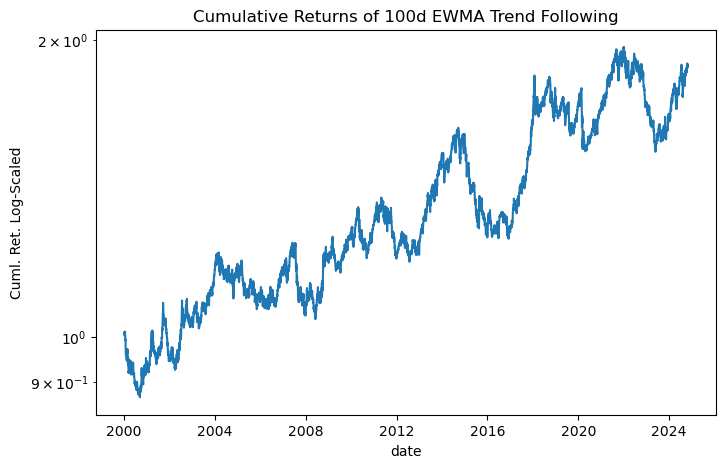

In [18]:
(df_es[
    ["vol_rtn"]].
    dropna().
    apply(lambda x: np.cumprod(1 + x)).
    plot(
        logy    = True,
        legend  = False,
        ylabel  = "Cuml. Ret. Log-Scaled",
        title   = "Cumulative Returns of 100d EWMA Trend Following",
        figsize = (8,5)))

plt.show()

In [19]:
df_trend = (df_es[
    ["vol_rtn"]])

In [20]:
def _run_regression(df: pd.DataFrame,
                    endog_dict: dict,
                    min_obs: int = 60) -> pd.DataFrame:

    df_out = pd.DataFrame()

    for key, tickers in endog_dict.items():

        df_tmp = (
            df.assign(
                ticker=lambda x: x.variable.str.split(" ").str[0]
            )
            .query("ticker == @tickers")
            .reset_index()
            .pivot(
                index=["date", "vol_rtn"],
                columns="ticker",
                values="value",
            )
            .dropna()
            .reset_index()
            .set_index("date")
            .sort_index()
        )

        y = df_tmp["vol_rtn"]
        X = sm.add_constant(df_tmp[tickers])

        # -------------------
        # In-sample regression
        # -------------------
        model = sm.OLS(y, X).fit()

        is_pred = model.fittedvalues

        # -------------------
        # Expanding OOS regression
        # -------------------
        rols = RollingOLS(
            endog=y,
            exog=X,
            min_nobs=min_obs,
            expanding=True,
        ).fit()

        oos_pred = (X * rols.params.shift(1)).sum(axis=1)

        df_add = (
            df_tmp.assign(
                is_y_pred=is_pred,
                is_signal_rtn=lambda x: np.sign(x.is_y_pred) * x.vol_rtn,
                oos_y_pred=oos_pred,
                oos_signal_rtn=lambda x: np.sign(x.oos_y_pred) * x.vol_rtn,
                name=key,
            )[[
                "vol_rtn",
                "is_y_pred",
                "is_signal_rtn",
                "oos_y_pred",
                "oos_signal_rtn",
                "name",
            ]]
        )

        df_out = pd.concat([df_out, df_add])

    return df_out


df_signal_rtn = (
    df_exog.assign(
        date=lambda x: pd.to_datetime(x.date).dt.date
    )
    .merge(
        right=df_trend,
        how="inner",
        on=["date"],
    )
    .dropna()
    .set_index("date")
    .groupby("var_type")
    .apply(_run_regression, exog_dict)
    .reset_index()
)

var_dict  = {"z_score": "Z-Score", "diff_val": "Differenced"}

In [21]:
df_signal_tmp = (df_signal_rtn.assign(
    var_type = lambda x: x.var_type.map(var_dict)).
    drop(columns = ["is_y_pred", "oos_y_pred"]).
    melt(id_vars = ["var_type", "date", "vol_rtn", "name"]))

In [22]:
def _get_avg(df: pd.DataFrame) -> pd.DataFrame: 

    df_out = (df.pivot(
        index = ["date", "vol_rtn"], columns = "plot_name", values = "value").
        assign(avg_ex = lambda x: x.mean(axis = 1)).
        reset_index().
        set_index(["date", "avg_ex"]).
        assign(avg_all = lambda x: x.mean(axis = 1)).
        reset_index().
        melt(id_vars = "date"))

    return df_out

df_plot = (df_signal_tmp.assign(
    plot_name = lambda x: x.name + " " + x.var_type).
    groupby("ticker").
    apply(_get_avg).
    reset_index().
    drop(columns = ["level_1"]))

In [23]:
avg_renamer = {
    "avg_ex" : "Avg (ex.Trend)",
    "avg_all": "Avg (All)",
    "vol_rtn": "Original Trend"}

plot_dict = {
    "Comparing Portfolio": ["Avg (ex.Trend)", "Avg (All)", "Original Trend"],
    "Comparing Signal"   : ["Original Trend", "3M Differenced", "3M Z-Score", "50D Differenced", "50D Z-Score"]}

sample_renamer = {
    "is_signal_rtn" : "In-Sample",
    "oos_signal_rtn": "Out-of-Sample"}

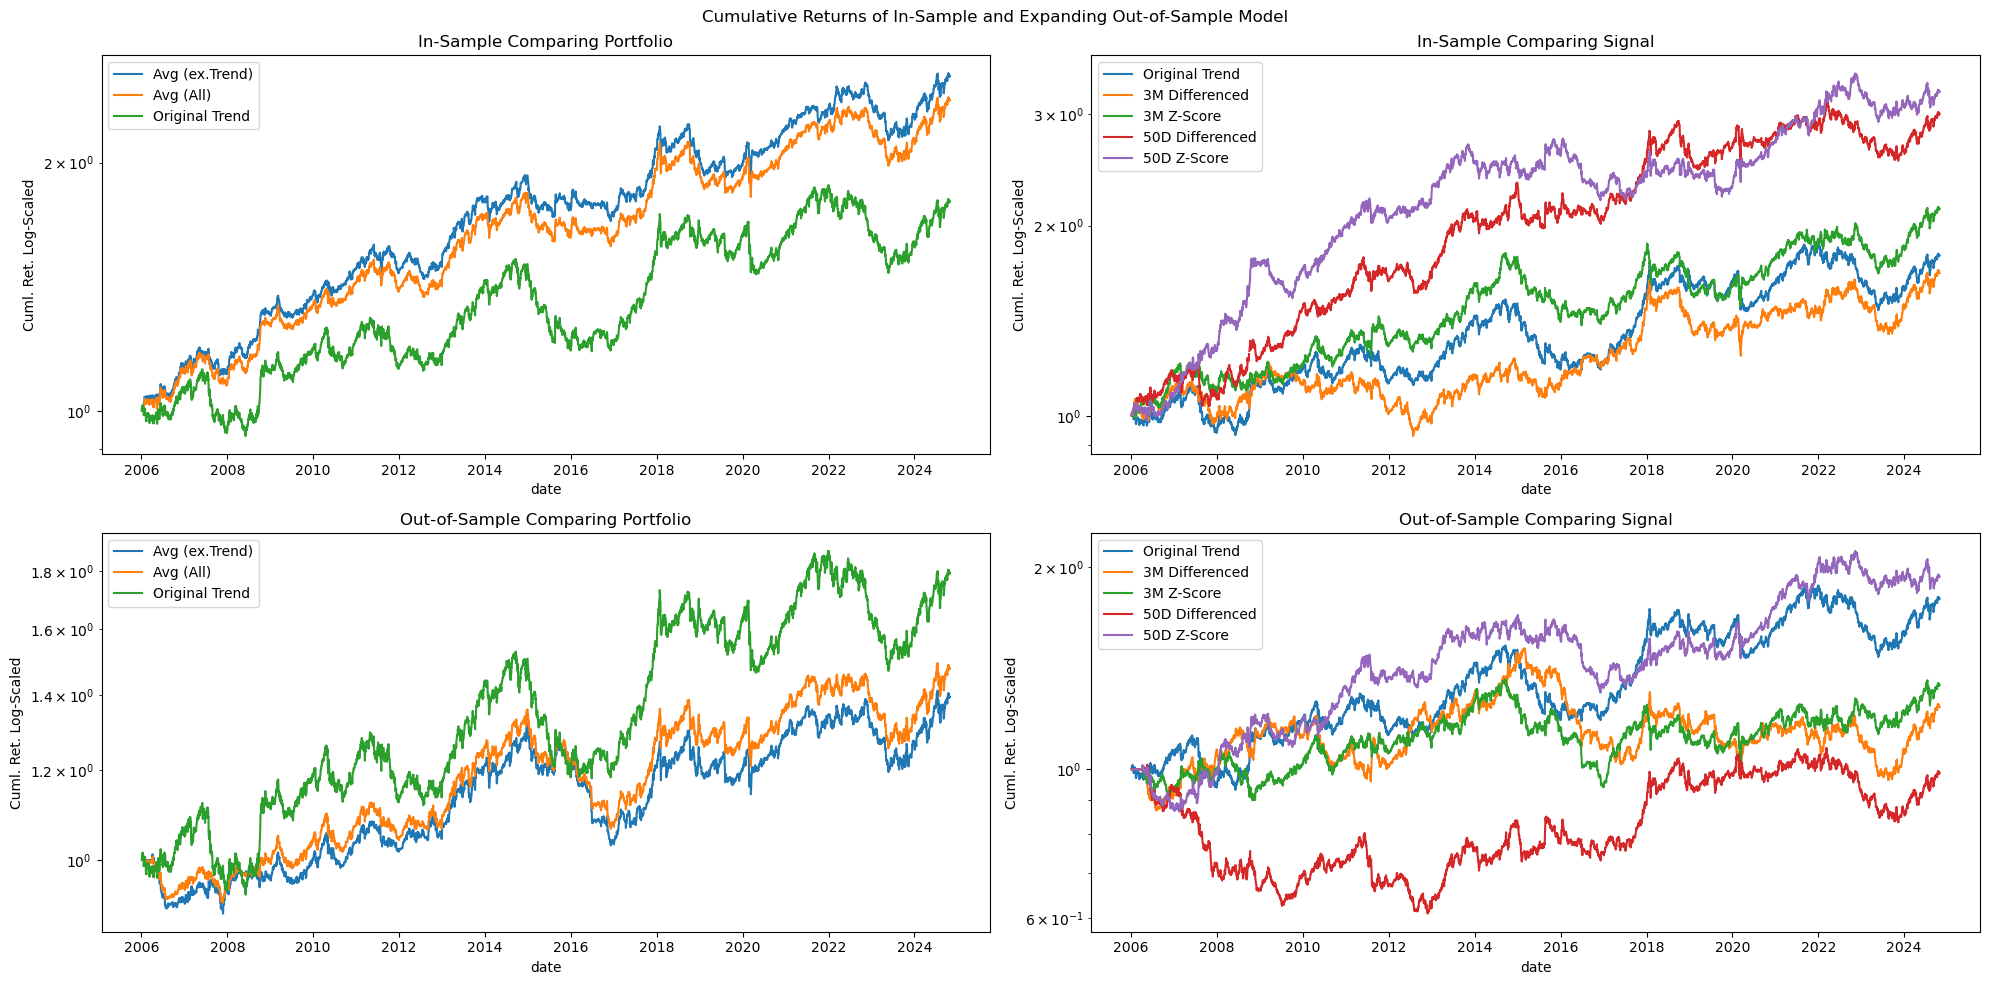

In [24]:
tickers  = df_plot.ticker.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = 2, nrows = 2, figsize = (20,10))

for i, ticker in enumerate(tickers): 

    df_wider = (df_plot.query(
        "ticker == @ticker").
        rename(columns = {"plot_name": ""}).
        pivot(index = "date", columns = "", values = "value").
        rename(columns = avg_renamer))

    for j, plot in enumerate(plot_dict.keys()):

        (df_wider[
            plot_dict[plot]].
            apply(lambda x: np.cumprod(1 + x)).
            plot(
                logy   = True,
                ax     = axes[i,j],
                ylabel = "Cuml. Ret. Log-Scaled",
                title  = sample_renamer[ticker] + " " + plot))

fig.suptitle("Cumulative Returns of In-Sample and Expanding Out-of-Sample Model")
plt.tight_layout()

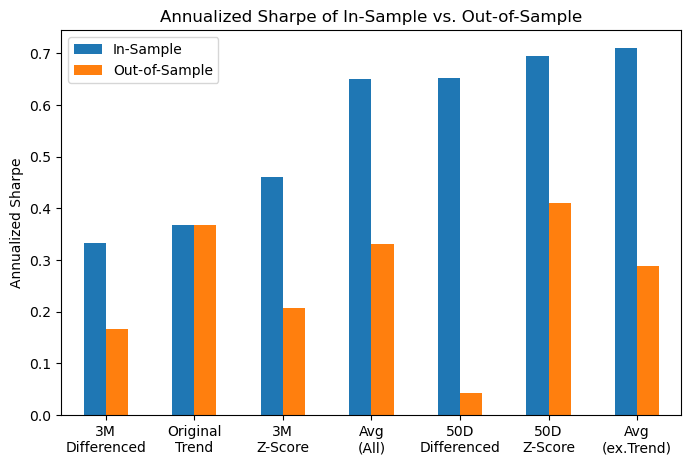

In [25]:
(df_plot.drop(
    columns = ["date"]).
    groupby(["ticker", "plot_name"]).
    agg(lambda x: x.mean() / x.std() * np.sqrt(252)).
    reset_index().
    rename(columns = {"ticker": ""}).
    pivot(index = "plot_name", columns = "", values = "value").
    reset_index().
    replace(avg_renamer).
    assign(plot_name = lambda x: x.plot_name.str.replace(" ","\n")).
    set_index("plot_name").
    sort_values(["is_signal_rtn", "oos_signal_rtn"]).
    rename(columns = sample_renamer).
    plot(
        kind    = "bar",
        xlabel  = "", 
        ylabel  = "Annualized Sharpe",
        title   = "Annualized Sharpe of In-Sample vs. Out-of-Sample",
        figsize = (8,5),
        rot     = 0))

plt.show()

# Examining the Principal Components

In [27]:
df_pc_exp, df_pc_val = pd.DataFrame(), pd.DataFrame()

for exog in exog_dict.keys():

    tickers  = exog_dict[exog]
    df_wider = (df_cboe.query(
        "variable == @tickers").
        pivot(index = "date", columns = "variable", values = "value").
        ffill())

    pca_model = PCA(n_components = len(df_wider.columns)).fit(df_wider)
    
    df_pc_exp_add = (pd.DataFrame({
        "exp_var": pca_model.explained_variance_ratio_}).
        reset_index().
        rename(columns = {"index": "PC"}).
        assign(
            name = exog,
            PC   = lambda x: x.PC + 1))

    df_pc_val_add = (pd.DataFrame(
        data    = pca_model.fit_transform(df_wider),
        columns = ["PC{}".format(i + 1) for i in range(len(df_wider.columns))],
        index   = df_wider.index).
        reset_index().
        melt(id_vars = "date").
        assign(name = exog))

    df_pc_exp = pd.concat([df_pc_exp, df_pc_exp_add])
    df_pc_val = pd.concat([df_pc_val, df_pc_val_add])

In [28]:
from sklearn.decomposition import PCA

df_pc_exp = pd.DataFrame()
df_pc_val = pd.DataFrame()
df_pc_loadings = pd.DataFrame()

for exog in exog_dict.keys():

    tickers = exog_dict[exog]

    df_wider = (
        df_cboe.query("variable == @tickers")
        .pivot(index="date", columns="variable", values="value")
        .ffill()
    )

    pca_model = PCA(n_components=len(df_wider.columns)).fit(df_wider)

    # Explained variance
    df_pc_exp_add = (
        pd.DataFrame({
            "PC": np.arange(1, len(df_wider.columns) + 1),
            "exp_var": pca_model.explained_variance_ratio_,
            "name": exog,
        })
    )

    # PC scores
    df_pc_val_add = (
        pd.DataFrame(
            pca_model.transform(df_wider),
            index=df_wider.index,
            columns=[f"PC{i}" for i in range(1, len(df_wider.columns) + 1)],
        )
        .reset_index()
        .melt(id_vars="date", var_name="PC", value_name="value")
        .assign(name=exog)
    )

    # Loadings
    df_pc_loadings_add = (
        pd.DataFrame(
            pca_model.components_,
            index=[f"PC{i}" for i in range(1, len(df_wider.columns) + 1)],
            columns=df_wider.columns,
        )
        .reset_index(names="PC")
        .melt(
            id_vars="PC",
            var_name="variable",
            value_name="loading",
        )
        .assign(name=exog)
    )

    df_pc_exp      = pd.concat([df_pc_exp, df_pc_exp_add], ignore_index=True)
    df_pc_val      = pd.concat([df_pc_val, df_pc_val_add], ignore_index=True)
    df_pc_loadings = pd.concat([df_pc_loadings, df_pc_loadings_add], ignore_index=True)

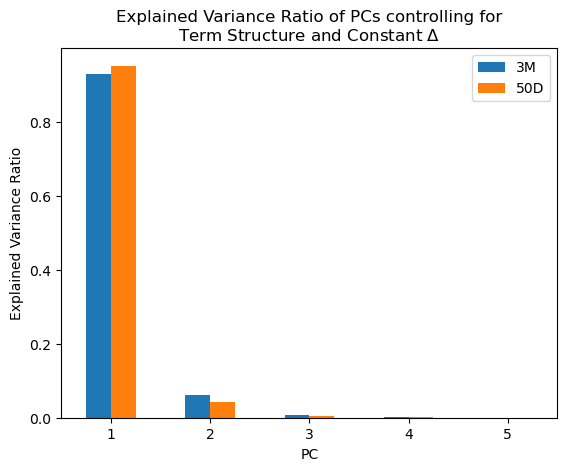

In [29]:
(df_pc_exp.rename(
    columns = {"name": ""}).
    pivot(index = "PC", columns = "", values = "exp_var").
    plot(
        rot    = 0,
        kind   = "bar",
        ylabel = "Explained Variance Ratio",
        title  = "Explained Variance Ratio of PCs controlling for\nTerm Structure and Constant $\Delta$"))

plt.show()

In [30]:
term_dict = (df_cboe_tickers.set_index(
    "ticker").
    window.
    to_dict())

delta_dict = (df_cboe_tickers.set_index(
    "ticker").
    delta.
    to_dict())

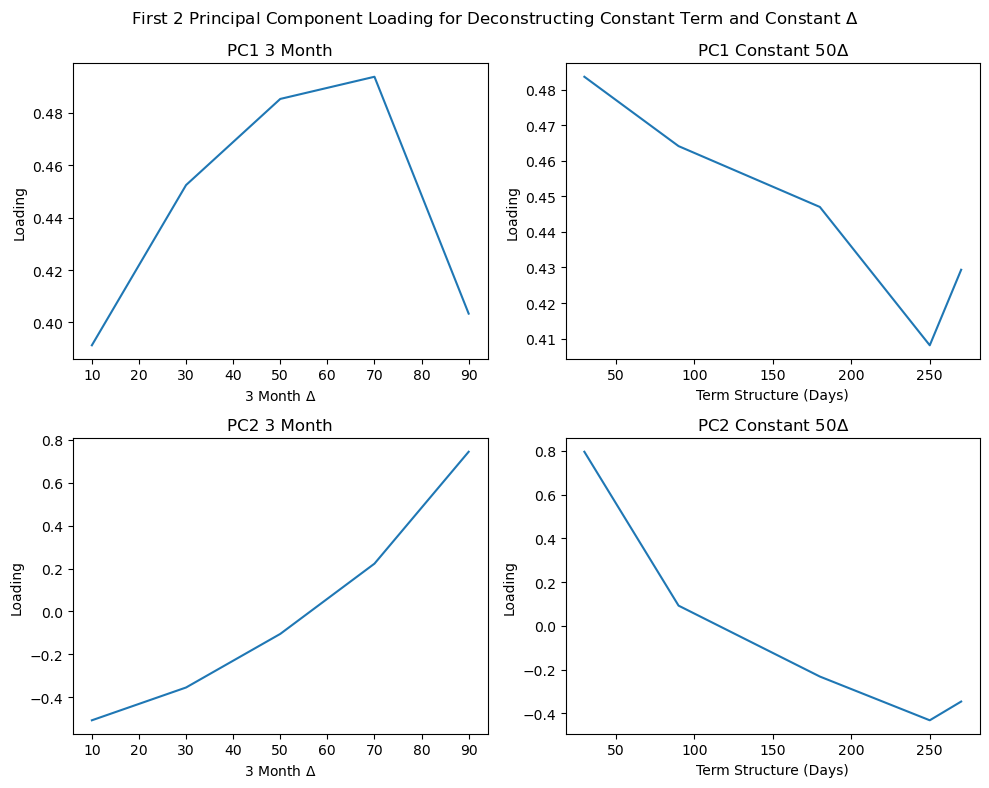

In [31]:
pcs = ["PC1", "PC2"]
fig, axes = plt.subplots(ncols = len(pcs), nrows = len(pcs), figsize = (10,8))

for i, pc in enumerate(pcs): 

    df_tmp = (df_pc_loadings.query(
        "PC == @pc"))

    (df_tmp.query(
        "name == '3M'").
        assign(delta = lambda x: x.variable.map(delta_dict)).
        set_index("delta")
        [["loading"]].
        plot(
            ylabel = "Loading",
            legend = False,
            ax     = axes[i,0],
            title  = pc + " 3 Month",
            xlabel = "3 Month $\Delta$"))

    (df_tmp.query(
        "name == '50D'").
        assign(term = lambda x: x.variable.map(term_dict)).
        sort_values("term").
        set_index("term")
        [["loading"]].
        plot(
            ylabel = "Loading",
            legend = False,
            ax     = axes[i,1],
            xlabel = "Term Structure (Days)",
            title  = pc + " Constant 50$\Delta$"))

fig.suptitle("First 2 Principal Component Loading for Deconstructing Constant Term and Constant $\Delta$")
plt.tight_layout()

The first term structure is mostly positive therefore it just an *average*-like value across the term/$\Delta$ structure. The second component captures a more interseting dynamic of term structure steepning or skewness

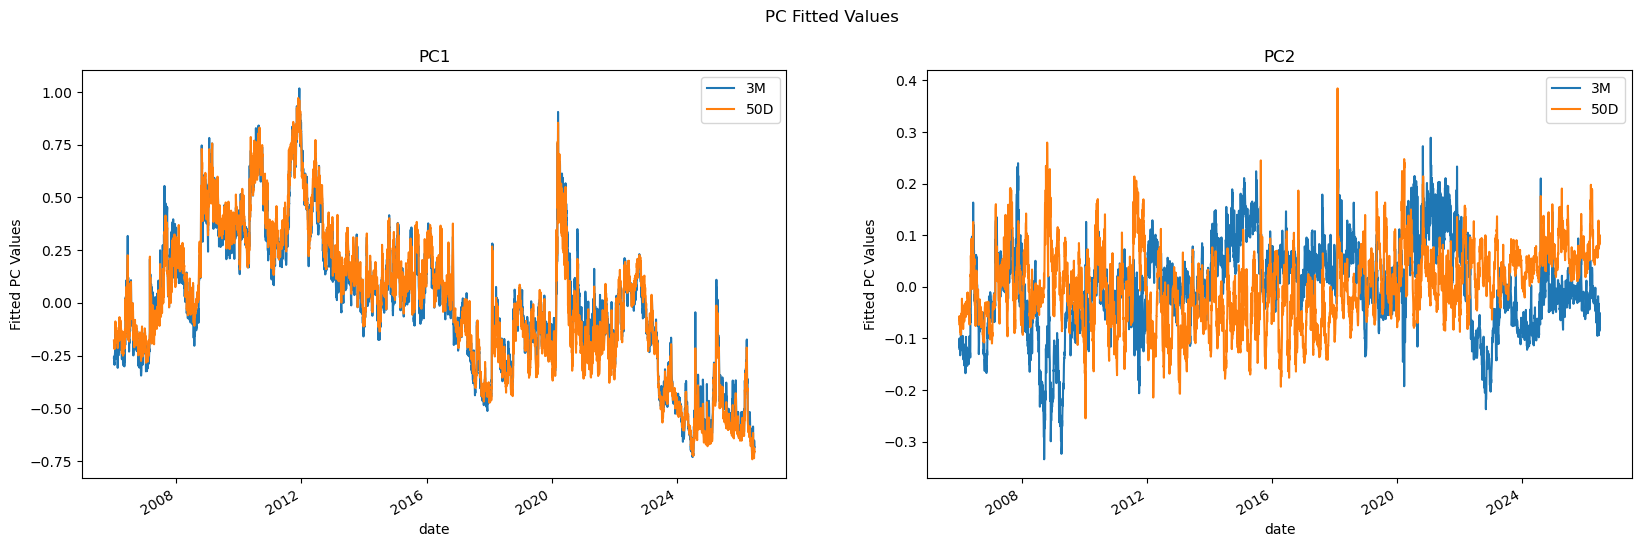

In [32]:
pcs = ["PC1", "PC2"]
fig, axes = plt.subplots(ncols = len(pcs), figsize = (20,6))

for pc, ax in zip(pcs, axes.flatten()):

    (df_pc_val.query(
        "PC == @pc").
        rename(columns = {"name": ""}).
        pivot(index = "date", columns = "", values = "value").
        plot(
            ax     = ax,
            ylabel = "Fitted PC Values",
            title  = pc))

fig.suptitle("PC Fitted Values")
plt.show()

In [33]:
def _get_transformation(df: pd.DataFrame, window: int = 30) -> pd.DataFrame: 

    df_out = (df.assign(
        diff_val = lambda x: x.value.diff(),
        z_score  = lambda x: (x.value - x.value.ewm(span = window, adjust = False).mean()) / x.value.ewm(span = window, adjust = False).std()).
        drop(columns = ["value"]).
        shift().
        reset_index().
        melt(id_vars = "date").
        dropna())

    return df_out

df_pc_signal = (df_pc_val.query(
    "PC == 'PC2'")
    [["date", "name", "value"]].
    set_index("date").
    groupby("name").
    apply(_get_transformation).
    reset_index().
    drop(columns = ["level_1"]))

In [34]:
def _get_ols_params(df: pd.DataFrame) -> pd.DataFrame: 

    model = (
        sm.OLS(
            endog=df["vol_rtn"],
            exog=sm.add_constant(df["value"])
        )
        .fit()
    )

    df_param = model.params.to_frame(name="param").reset_index()
    df_pvalue = model.pvalues.to_frame(name="p_value").reset_index()
    df_stat = model.tvalues.to_frame(name="t_stat").reset_index()

    return (
        df_param
        .merge(df_pvalue, on="index")
        .merge(df_stat, on="index")
        .rename(columns={"index": "variable"})
    )


df_params = (df_pc_signal.assign(
    date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_trend, how = "inner", on = ["date"]).
    set_index("date").
    assign(group_var = lambda x: x.name + " " + x.variable).
    groupby("group_var").
    apply(_get_ols_params).
    reset_index().
    drop(columns = ["level_1"]))

In [35]:
(df_params.assign(
    model = lambda x: x.group_var.str.split(" ").str[0],
    signal = lambda x: x.group_var.str.split(" ").str[1].map(var_dict)).
    drop(columns = ["group_var"]).
    rename(columns = {
        "param"   : "param_val",
        "variable": "param_name"})
    [["signal", "model", "param_name", "param_val", "p_value", "t_stat"]].
    rename(columns = {
        "signal"    : "Signal",
        "model"     : "Model",
        "param_name": "Param Name",
        "param_val" : "Param Val"}))

,Signal,Model,Param Name,Param Val,p_value,t_stat
0,Differenced,3M,const,0.000131,0.143814,1.461976
1,Differenced,3M,value,-0.000180,0.954844,-0.056628
2,Z-Score,3M,const,0.000131,0.144610,1.459079
3,Z-Score,3M,value,0.000058,0.551720,0.595227
4,Differenced,50D,const,0.000131,0.144133,1.460814
5,Differenced,50D,value,0.003364,0.359037,0.917290
6,Z-Score,50D,const,0.000131,0.144122,1.460854
7,Z-Score,50D,value,0.000023,0.814056,0.235210


In [36]:
def _get_ols_params(df: pd.DataFrame) -> pd.DataFrame: 

    model = (
        sm.OLS(
            endog=df["vol_rtn"],
            exog=sm.add_constant(df["value"])
        )
        .fit()
    )

    df_param = model.params.to_frame(name="param").reset_index()
    df_pvalue = model.pvalues.to_frame(name="p_value").reset_index()
    df_stat = model.tvalues.to_frame(name="t_stat").reset_index()

    return (
        df_param
        .merge(df_pvalue, on="index")
        .merge(df_stat, on="index")
        .rename(columns={"index": "variable"})
    )

df_pc_combined = (df_pc_val.query(
    "PC == 'PC2'")
    [["date", "name", "value"]].
    pivot(index = "date", columns = "name", values = "value").
    shift().
    reset_index().
    melt(id_vars = "date", value_name = "value").
    dropna().
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    merge(right = df_trend, how = "inner", on = ["date"]).
    set_index("date"))

In [37]:
(df_pc_combined.groupby(
    "name").
    apply(_get_ols_params).
    reset_index().
    drop(columns = ["level_1"]).
    rename(columns = {"variable": "param_name"}).
    melt(id_vars = ["name", "param_name"]).
    rename(columns = {
        "variable"  : "",
        "name"      : "Constant",
        "param_name": "Param"}).
    replace({
        "const"  : r"$\alpha$",
        "value"  : r"$\beta$",
        "p_value": r"$p$-value",
        "t_stat" : r"$t$-stat"}).
    pivot(index = "Constant", columns = ["", "Param"], values = "value"))

param           $p$-value            $t$-stat          
Param     $\alpha$   $\beta$  $\alpha$   $\beta$  $\alpha$   $\beta$
Constant                                                            
3M        0.000131  0.000633  0.144390  0.533155  1.459879  0.623243
50D       0.000127 -0.000764  0.157823  0.540787  1.412654 -0.611668

In [60]:
def _get_ols_signal(df: pd.DataFrame,
                    min_obs: int = 60) -> pd.DataFrame:

    df = df.sort_index()

    y = df["vol_rtn"]
    X = sm.add_constant(df["value"])

    # -------------------
    # In-sample regression
    # -------------------
    model = sm.OLS(y, X).fit()

    is_pred = model.fittedvalues

    # -------------------
    # Expanding OOS regression
    # -------------------
    rols = RollingOLS(
        endog=y,
        exog=X,
        min_nobs=min_obs,
        expanding=True,
    ).fit()

    oos_pred = (X * rols.params.shift(1)).sum(axis=1)

    return (
        df.assign(
            is_y_pred=is_pred,
            is_signal_rtn=lambda x: np.sign(x.is_y_pred) * x.vol_rtn,
            oos_y_pred=oos_pred,
            oos_signal_rtn=lambda x: np.sign(x.oos_y_pred) * x.vol_rtn,
        )
    )


df_tmp = (df_pc_combined.query("name == name.min()").groupby(
    "name").
    apply(_get_ols_signal).
    reset_index())

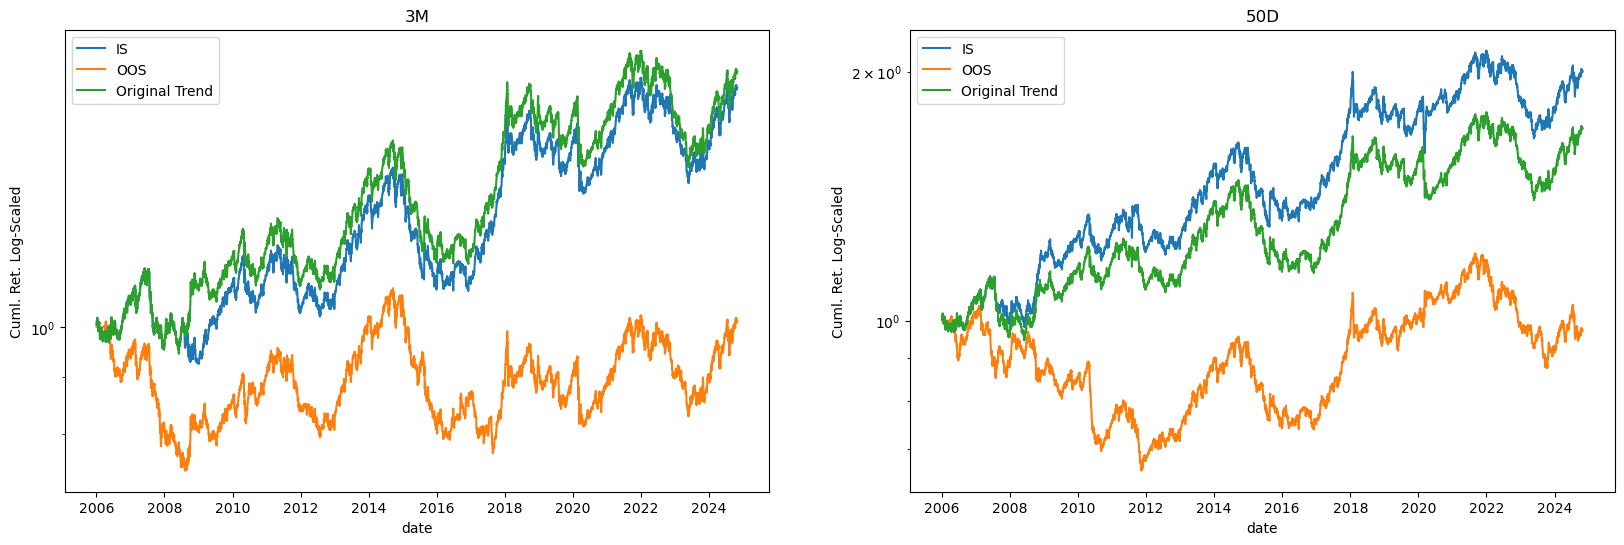

In [65]:
df_longer = (df_pc_rtn.drop(
    columns = ["is_y_pred", "oos_y_pred", "value"]).
    melt(id_vars = ["date", "name"]))

names     = df_longer.name.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(names), figsize = (20,6))

for name, ax in zip(names, axes.flatten()):

    (df_longer.query(
        "name == @name").
        rename(columns = {"variable": ""}).
        pivot(index = "date", columns = "", values = "value").
        rename(columns = {
            "is_signal_rtn" : "IS",
            "oos_signal_rtn": "OOS",
            "vol_rtn"       : "Original Trend"}).
        apply(lambda x: np.cumprod(1 + x)).
        plot(
            logy   = True,
            ax     = ax,
            ylabel = "Cuml. Ret. Log-Scaled",
            title  = name))